# M6: CVD gamut as a diagnostic

Implements proposal 2 from `docs/ssvep_analyses.md` (PLAN milestone M6) -- the
one well-powered effect in this dataset (Fisher exact p=0.0019 for
`fitted_at_bound` between CVD and CTR) and the lever for the project's bifold
goal: (1) does this person have a CVD at all, and (2) if so, is it deutan or
protan. Sections 1-3 build the diagnostic and a continuous measure usable for
every CVD subject, not just the ones with an interior trough; section 4 is
where that continuous measure gets its first test against the actual
subtyping question.

In [1]:
import sys
sys.path.append('../scripts')

import numpy as np
import pandas as pd
from scipy import stats

import analysis as an
import plotting

runmap_df = an.load_runmap()
baselines_df = an.load_baselines()
metadata_df = an.load_metadata()
red_vals, green_vals = an.load_grid_axes()

SESSION = 1
troughs_df = pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
s1 = troughs_df[troughs_df['session'] == SESSION]

## Understanding bootstrap confidence intervals

This notebook uses `analysis.bootstrap_ci` twice (sensitivity/specificity
below, and the extrapolation CI in section 3), so it's worth seeing what it
does before trusting its output. The idea: you have one sample and one
statistic computed from it (a proportion, a slope, anything). You don't know
how much that statistic would wobble on a different sample of the same size
from the same population -- but you can approximate that by **resampling
your own data with replacement**, many times, recomputing the statistic each
time. The spread of those recomputed values stands in for "how much would
this wobble on a new sample."

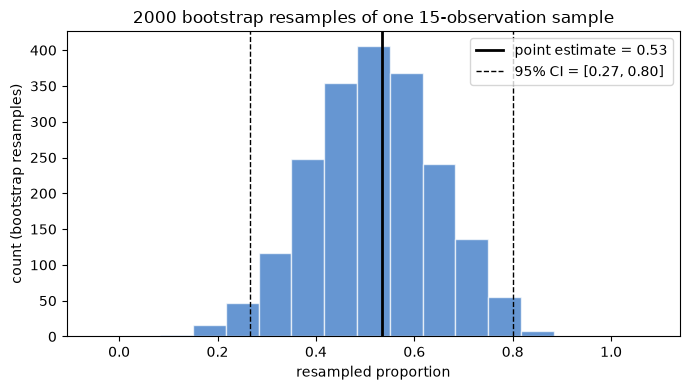

In [2]:
import matplotlib.pyplot as plt
from plotting import DISTRIBUTION_COLOR

rng_demo = np.random.default_rng(0)
sample = rng_demo.binomial(1, 0.7, size=15)  # 15 synthetic yes/no observations
point = sample.mean()

def replicate(rng):
    return rng.choice(sample, size=len(sample), replace=True).mean()

replicates = np.array([replicate(rng_demo) for _ in range(2000)])
lo, hi = np.quantile(replicates, [0.025, 0.975])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(replicates, bins=np.arange(-0.05, 1.1, 1 / 15), color=DISTRIBUTION_COLOR, alpha=0.7, edgecolor='white')
ax.axvline(point, color='black', linewidth=2, label=f'point estimate = {point:.2f}')
ax.axvline(lo, color='black', linestyle='--', linewidth=1, label=f'95% CI = [{lo:.2f}, {hi:.2f}]')
ax.axvline(hi, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('resampled proportion')
ax.set_ylabel('count (bootstrap resamples)')
ax.set_title('2000 bootstrap resamples of one 15-observation sample')
ax.legend()
fig.tight_layout()

That's the whole mechanism -- 2000 "what if I'd drawn a slightly different
15 samples" replays of one real sample, with the middle 95% of the results
kept as the interval. Two things worth internalizing before section 1: the
CI is only as good as the original sample (bootstrap can't manufacture
information that isn't there -- a small or biased sample gives a small or
biased bootstrap), and it needs a `replicate_fn` that resamples the right
*unit*. Below, that unit is subjects (resample which subjects, not which
pixels); in section 3's extrapolation CI, it's runs (resample which of a
subject's own runs). Get the resampling unit wrong -- e.g. resampling
individual pixels of a grid instead of whole subjects -- and the CI would
describe the wrong source of uncertainty entirely.

## 1. `fitted_at_bound` as a CVD/CTR diagnostic, with a bootstrap CI

Point estimate only, from the earlier work: 11/15 CVD subjects pegged at a
sampled-range bound vs. 4/21 CTR (Fisher exact p=0.0019, odds ratio 11.7).
Both proportions are computed on the same 42 subjects that motivated looking
for this cutoff in the first place, so a plain point estimate overstates how
precisely they're known -- a subject-level bootstrap (resample subjects
within each group, with replacement, recompute the proportion) gives an
honest CI instead.

In [3]:
cvd_ctr = s1[s1['group'].isin(['CVD', 'CTR'])]

sens = s1.loc[s1['group'] == 'CVD', 'fitted_at_bound'].mean()
spec = 1 - s1.loc[s1['group'] == 'CTR', 'fitted_at_bound'].mean()
print(f"sensitivity (CVD at_bound):     {sens:.3f}  ({s1.loc[s1['group']=='CVD','fitted_at_bound'].sum()}/{(s1['group']=='CVD').sum()})")
print(f"specificity (CTR not at_bound): {spec:.3f}  ({(~s1.loc[s1['group']=='CTR','fitted_at_bound']).sum()}/{(s1['group']=='CTR').sum()})")

def boot_prop(arr):
    return an.bootstrap_ci(lambda rng: rng.choice(arr, size=len(arr), replace=True).mean(), n_boot=2000, seed=0)

sens_ci = boot_prop(s1.loc[s1['group'] == 'CVD', 'fitted_at_bound'].to_numpy())
spec_ci = boot_prop((~s1.loc[s1['group'] == 'CTR', 'fitted_at_bound']).to_numpy())
print(f"sensitivity 95% bootstrap CI:   [{sens_ci[0]:.3f}, {sens_ci[1]:.3f}]")
print(f"specificity 95% bootstrap CI:   [{spec_ci[0]:.3f}, {spec_ci[1]:.3f}]")

table = pd.crosstab(cvd_ctr['group'] == 'CVD', cvd_ctr['fitted_at_bound'])
odds, p = stats.fisher_exact(table)
print(f"\nFisher exact (CVD vs CTR only): odds ratio={odds:.1f}, p={p:.4f}")
table

sensitivity (CVD at_bound):     0.733  (11/15)
specificity (CTR not at_bound): 0.810  (17/21)
sensitivity 95% bootstrap CI:   [0.467, 0.933]
specificity 95% bootstrap CI:   [0.619, 0.952]

Fisher exact (CVD vs CTR only): odds ratio=11.7, p=0.0019


fitted_at_bound,False,True
group,,
False,17,4
True,4,11


Both CIs are wide -- expected at n=15/n=21 -- but neither comes close to
crossing 0.5, and specificity's lower bound (~0.62) still clears chance. This
is the one comparison in the dataset that survives an honest CI, which is
exactly what proposal 1 said to expect from the only well-powered effect
here.

## Understanding why a ramp-only fit is needed

`fit_ramp_gaussian` (M4) fits a ramp *plus* a Gaussian dip on top of it --
that's the right model when a subject's trough actually sits inside the
sampled grid. But when the true trough is beyond the sampled range, there's
no dip in the data to find, and the optimizer has nowhere honest to put one:
it pushes the dip's center to the edge of the allowed range and reports
`at_bound=True`. `fit_ramp` sidesteps the problem by not assuming a dip
exists at all -- it only ever fits the straight-line trend, so it can't peg.

fit_ramp_gaussian: red=3200  at_bound=True  fit_valid=False
fit_ramp:          slope_red=-0.000343  (true slope: -0.0003)


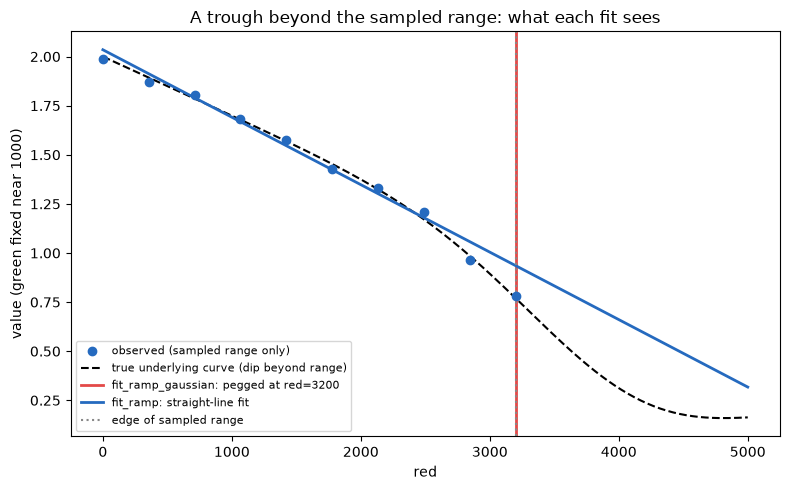

In [4]:
rng_demo = np.random.default_rng(0)
red_demo = list(np.linspace(0, 3200, 10))
green_demo = list(np.linspace(0, 2000, 10))
Xg, Yg = np.meshgrid(red_demo, green_demo, indexing='ij')
true_dip_red = 4200.0  # beyond the sampled range (max sampled red is 3200)
true_grid = (2.0 - 0.0003 * Xg
             - 0.5 * np.exp(-(((Xg - true_dip_red) ** 2) / (2 * 900.0 ** 2) + ((Yg - 1000.0) ** 2) / (2 * 600.0 ** 2))))
demo_grid = true_grid + rng_demo.normal(0, 0.02, true_grid.shape)

rg_fit = an.fit_ramp_gaussian(demo_grid, red_demo, green_demo)
ramp_fit = an.fit_ramp(demo_grid, red_demo, green_demo)
print(f"fit_ramp_gaussian: red={rg_fit['red']:.0f}  at_bound={rg_fit['at_bound']}  fit_valid={rg_fit['fit_valid']}")
print(f"fit_ramp:          slope_red={ramp_fit['slope_red']:.6f}  (true slope: -0.0003)")

green_idx = np.argmin(np.abs(np.array(green_demo) - 1000))
red_extended = np.linspace(0, 5000, 200)
true_cross_section = (2.0 - 0.0003 * red_extended
                       - 0.5 * np.exp(-((red_extended - true_dip_red) ** 2) / (2 * 900.0 ** 2)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(red_demo, demo_grid[:, green_idx], color=DISTRIBUTION_COLOR, label='observed (sampled range only)', zorder=3)
ax.plot(red_extended, true_cross_section, 'k--', label='true underlying curve (dip beyond range)')
ax.axvline(rg_fit['red'], color='#e34948', linewidth=2, label=f"fit_ramp_gaussian: pegged at red={rg_fit['red']:.0f}")
ramp_line = ramp_fit['intercept'] + ramp_fit['slope_red'] * red_extended + ramp_fit['slope_green'] * green_demo[green_idx]
ax.plot(red_extended, ramp_line, color='#256abf', linewidth=2, label='fit_ramp: straight-line fit')
ax.axvline(3200, color='#888888', linestyle=':', label='edge of sampled range')
ax.set_xlabel('red')
ax.set_ylabel('value (green fixed near 1000)')
ax.legend(fontsize=8)
ax.set_title('A trough beyond the sampled range: what each fit sees')
fig.tight_layout()

The dashed black curve is the ground truth: a real dip exists, just past
red=4200, entirely outside the sampled 0-3200 range. `fit_ramp_gaussian`
(red vertical line) has no way to know that -- all it can see is the blue
dots, which look monotonically decreasing, so it pegs its dip's center
exactly at the sampled edge (`at_bound=True`) rather than inventing a
location it has no evidence for. `fit_ramp` (blue line) doesn't try to find
a dip at all, so it just fits the visible trend -- and recovers the true
slope (-0.0003) almost exactly, because that part of the true curve really
is close to linear over the sampled range. Neither fit can tell you *where*
the real dip is from this data alone; `fit_ramp` is just honest about not
trying, which is what makes its slope usable as a comparable number across
every pegged subject in section 2.

## 2. Ramp-only slope: a measure every CVD subject has

`fit_ramp` (M6, `analysis.py`) fits just the linear term `z = c0 + c1*x +
c2*y`, no dip -- so it has no interior minimum to fail to find, and
`ramp_slope_red` is defined for all 15 CVD subjects at session 1, pegged or
not (persisted in `subject_troughs.csv` for every subject/session, not just
CVD).

In [5]:
cvd_s1 = s1[s1['subgroup'].isin(['protan', 'deutan'])]
cvd_s1[['sub_id', 'subgroup', 'fitted_at_bound', 'fitted_valid', 'ramp_slope_red']].sort_values('subgroup')

,sub_id,subgroup,fitted_at_bound,fitted_valid,ramp_slope_red
22,MET015,deutan,False,True,-0.000009
43,MET029,deutan,True,False,-0.000103
47,MET032,deutan,True,False,0.000013
48,MET033,deutan,False,True,-0.000030
49,MET034,deutan,True,False,-0.000085
58,MET043,deutan,True,False,-0.000137
59,MET044,deutan,True,False,-0.000039
23,MET016,protan,False,True,-0.000066
25,MET017,protan,False,True,0.000048
42,MET028,protan,True,False,-0.000019


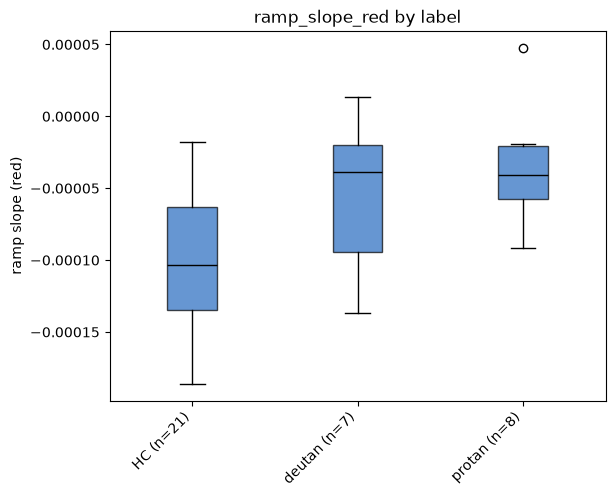

In [6]:
compare_df = s1[(s1['group'] == 'CTR') | s1['subgroup'].isin(['protan', 'deutan'])].copy()
compare_df['label'] = np.where(compare_df['group'] == 'CTR', 'HC', compare_df['subgroup'])
plotting.plot_troughs_boxplot(compare_df, 'ramp_slope_red', 'label', ylabel='ramp slope (red)');

CTR's slope (median ~-0.00010) is markedly steeper than protan's (~-0.00004)
and deutan's (~-0.00006) -- consistent with the physiological story:
protanopes need much more red before the response falls appreciably, so their
descending ramp is shallower over the sampled range. This alone is a
candidate CVD-vs-HC feature; section 4 asks whether it also separates the two
subtypes.

## Understanding why extrapolation is risky

Section 3 extends a fitted straight line past the sampled data to find where
it would cross some target value -- ordinary algebra, `red = (target -
intercept) / slope`. The risk isn't the algebra, it's that a line fit to
data in one range gets *less* certain the further you extend it outside that
range, and that uncertainty isn't linear: it's roughly proportional to how
far past the data you're asking, and it blows up entirely as the slope
approaches zero (dividing by a number close to zero).

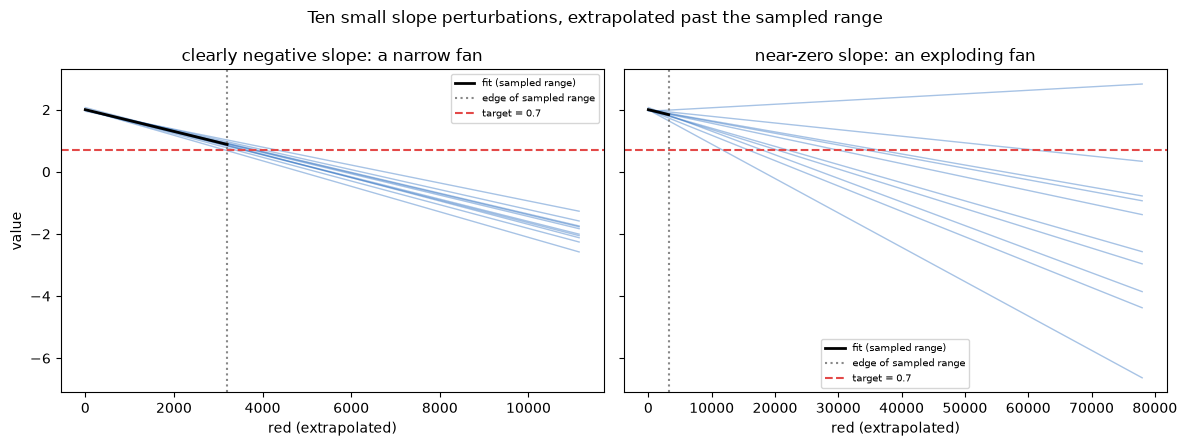

In [7]:
def crossing_fan(ax, true_slope, slope_noise, title):
    rng = np.random.default_rng(3)
    true_intercept, target = 2.0, 0.7
    x_sampled = np.linspace(0, 3200, 10)
    x_extended = np.linspace(0, max(9000, 3 * (target - true_intercept) / true_slope), 200)
    ax.plot(x_sampled, true_intercept + true_slope * x_sampled, color='black', linewidth=2, zorder=3, label='fit (sampled range)')
    for _ in range(10):
        slope = true_slope + rng.normal(0, slope_noise)
        intercept = true_intercept + rng.normal(0, 0.02)
        ax.plot(x_extended, intercept + slope * x_extended, color=DISTRIBUTION_COLOR, alpha=0.4, linewidth=1)
    ax.axvline(3200, color='#888888', linestyle=':', label='edge of sampled range')
    ax.axhline(target, color='#e34948', linestyle='--', label=f'target = {target}')
    ax.set_xlabel('red (extrapolated)')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
crossing_fan(axes[0], true_slope=-0.00035, slope_noise=0.00003, title='clearly negative slope: a narrow fan')
crossing_fan(axes[1], true_slope=-0.00005, slope_noise=0.00003, title='near-zero slope: an exploding fan')
axes[0].set_ylabel('value')
fig.suptitle('Ten small slope perturbations, extrapolated past the sampled range')
fig.tight_layout()

Same small amount of slope noise in both panels -- only the true slope
changes. Left: a clearly negative slope, and the ten perturbed lines cross
the red target line in a reasonably narrow band. Right: a slope close to
zero, and the same-sized perturbation sends the crossing point anywhere from
just past the sampled range to tens of thousands of units away -- because
`(target - intercept) / slope` has `slope` in the denominator, and a small
absolute change in a near-zero number is a huge *relative* change. This is
exactly what happened to some of the real pegged subjects below: a subject
whose ramp happens to be nearly flat gets an extrapolated crossing point (and
CI) that swings wildly, not because anything is wrong with the fit, but
because the question "where would this nearly-flat line eventually cross a
target" is inherently close to unanswerable. Section 3 flags this explicitly
rather than reporting those numbers as if they were precise.

## 3. Extrapolating the ramp to where it would cross a trough

Answers "how far beyond the sampled red range would this subject's trough
need to be" for the 11 CVD subjects flagged `fitted_at_bound`. Target depth
and green position come from a *population* reference -- the median
`fitted_depth`/`fitted_green` among each subgroup's own `fitted_valid`
subjects -- not the pegged subject's own fit, which is exactly what
`fitted_at_bound` says not to trust.

**Caveat up front:** that reference is only 2 valid protan and 2 valid deutan
subjects (project-wide, both sessions -- see the table below). A median of 2
values is barely more than their average. Treat the reference numbers, and
therefore every extrapolated position below, as indicative rather than
precise -- worth having, not worth quoting to more than one significant
figure.

In [8]:
def reference(subgroup):
    valid = troughs_df[(troughs_df['subgroup'] == subgroup) & troughs_df['fitted_valid']]
    return valid['fitted_depth'].median(), valid['fitted_green'].median(), len(valid)

refs = {sg: reference(sg) for sg in ('protan', 'deutan')}
pd.DataFrame(refs, index=['target_depth', 'green_ref', 'n_valid']).T

,target_depth,green_ref,n_valid
protan,0.208018,841.706653,2.0
deutan,0.088140,553.123506,2.0


In [9]:
pegged = s1[s1['subgroup'].isin(['protan', 'deutan']) & s1['fitted_at_bound']]

rows = []
for _, row in pegged.iterrows():
    grids = an.run_grids(runmap_df, baselines_df, row['sub_id'], SESSION, an.DEFAULT_NORMALIZE)
    ramp = an.fit_ramp(np.mean(grids, axis=0), red_vals, green_vals)
    target_depth, green_ref, _ = refs[row['subgroup']]
    point = an.extrapolate_ramp_crossing(ramp, target_depth, green_ref)

    def replicate(rng, grids=grids, target_depth=target_depth, green_ref=green_ref):
        idx = rng.integers(0, len(grids), size=len(grids))
        r = an.fit_ramp(np.mean([grids[i] for i in idx], axis=0), red_vals, green_vals)
        return an.extrapolate_ramp_crossing(r, target_depth, green_ref) if r['slope_red'] != 0 else np.nan

    lo, hi = an.bootstrap_ci(replicate, n_boot=2000, seed=0)
    rows.append({'sub_id': row['sub_id'], 'subgroup': row['subgroup'],
                 'extrapolated_red': point, 'ci_lo': lo, 'ci_hi': hi})

extrap_df = pd.DataFrame(rows)
extrap_df['beyond_sampled_range'] = extrap_df['extrapolated_red'] > max(red_vals)
extrap_df.round(0)

,sub_id,subgroup,extrapolated_red,ci_lo,ci_hi,beyond_sampled_range
0,MET028,protan,26172.0,20170.0,39785.0,True
1,MET029,deutan,3944.0,2487.0,5916.0,True
2,MET031,protan,6727.0,-19028.0,36959.0,True
3,MET032,deutan,-3535.0,-9041.0,-1134.0,False
4,MET034,deutan,4773.0,3758.0,6248.0,True
5,MET035,protan,9004.0,6825.0,13567.0,True
6,MET036,protan,10153.0,-191542.0,83592.0,True
7,MET043,deutan,4172.0,3564.0,5263.0,True
8,MET044,deutan,8930.0,7457.0,11650.0,True
9,MET045,protan,963.0,-1655.0,3358.0,False


8 of 11 pegged subjects' point estimates land beyond the sampled range (max
red = 3200), which is the qualitative confirmation the physiology predicts.
But look at the CIs, not just the points: several are enormous (MET036's
spans roughly [-190000, 84000]) or even land on the wrong side of zero
(MET032, MET045) -- both symptoms of dividing by a slope estimate that's
close to zero for that particular subject, which a linear extrapolation is
inherently unstable against. **This extrapolated position is not a reliable
per-subject number.** Use it only as group-level, qualitative support for
"the trough is out there somewhere" -- for anything that needs a stable
per-subject value (comparisons, further modeling), `ramp_slope_red` from
section 2 is the measure to use; it doesn't blow up.

## 4. Does either measure separate protan from deutan?

The question section 2 set up, and the actual subtype half of the bifold
goal. `ramp_slope_red` is well-behaved for all 15 CVD subjects, so that's the
primary test; the extrapolated crossing is included only as a secondary
check, with the section 3 caveat in force.

In [10]:
protan_slope = s1.loc[s1['subgroup'] == 'protan', 'ramp_slope_red']
deutan_slope = s1.loc[s1['subgroup'] == 'deutan', 'ramp_slope_red']

t, p_t = stats.ttest_ind(protan_slope, deutan_slope, equal_var=False)
u, p_u = stats.mannwhitneyu(protan_slope, deutan_slope, alternative='two-sided')
pooled_sd = np.sqrt((protan_slope.std() ** 2 + deutan_slope.std() ** 2) / 2)
d = (protan_slope.mean() - deutan_slope.mean()) / pooled_sd

print(f"ramp_slope_red -- protan n={len(protan_slope)} mean={protan_slope.mean():.2e}, "
      f"deutan n={len(deutan_slope)} mean={deutan_slope.mean():.2e}")
print(f"Welch t-test:    t={t:.2f}, p={p_t:.3f}")
print(f"Mann-Whitney U:  U={u:.0f}, p={p_u:.3f}")
print(f"Cohen's d:       {d:.2f}")

ramp_slope_red -- protan n=8 mean=-3.58e-05, deutan n=7 mean=-5.58e-05
Welch t-test:    t=0.79, p=0.444
Mann-Whitney U:  U=32, p=0.694
Cohen's d:       0.41


In [11]:
protan_extrap = extrap_df.loc[extrap_df['subgroup'] == 'protan', 'extrapolated_red']
deutan_extrap = extrap_df.loc[extrap_df['subgroup'] == 'deutan', 'extrapolated_red']
u2, p_u2 = stats.mannwhitneyu(protan_extrap, deutan_extrap, alternative='two-sided')
print(f"secondary check -- extrapolated crossing, pegged subjects only: "
      f"protan n={len(protan_extrap)}, deutan n={len(deutan_extrap)}")
print(f"Mann-Whitney U: U={u2:.0f}, p={p_u2:.3f}")

secondary check -- extrapolated crossing, pegged subjects only: protan n=6, deutan n=5
Mann-Whitney U: U=21, p=0.329


Neither test reaches significance (`ramp_slope_red`: Welch p=0.44,
Mann-Whitney p=0.69; extrapolated crossing: Mann-Whitney p=0.33). Protan's
slope is shallower than deutan's on average (consistent with protanopes
needing more red), and Cohen's d=0.41 is the same order of magnitude as the
PD-vs-CTR effect proposal 1 already showed is underpowered at this project's
sample sizes (d=0.45, n=6 vs 21, power=0.11) -- at n=7 vs 8 here the power is
worse still. **This is the honest answer to the subtype question right now:
there's a hint of a slope difference in the physiologically expected
direction, but this dataset cannot yet say it's real.** The measure itself
(`ramp_slope_red`) is sound and reusable -- what's missing is more protan and
deutan subjects, the same conclusion proposal 1 reached for PD.

## 5. Recommendation for future data collection

Everything above is consistent with the same physical story: a protanope's
isoluminant point sits at a higher red radiance than a trichromat's, and for
most of this dataset's CVD subjects that point lies beyond the sampled red
axis (0-3200). No amount of fitting recovers a location the grid never
sampled -- `ramp_slope_red` sidesteps that by not needing an interior minimum
at all, but it's a proxy, not the measurement anyone actually wants.
**Extend the red axis of the stimulus grid.** That's the concrete,
experimental (not analytical) recommendation this whole line of analysis
converges on, and it's the one change most likely to turn section 4's
suggestive-but-not-significant result into a real one.